In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:\\migratedData\\Rydberg_QIS\\data")

In [4]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR')


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
sr400 = SR400.SR400('GPIB0::23::INSTR',timeout=1000)

In [5]:
weeder = Weeder.Weeder("ASRL1::INSTR")

VisaIOError: VI_ERROR_RSRC_BUSY (-1073807246): The resource is valid, but VISA cannot currently access it.

In [9]:
weeder.position(header = "A", query = True)

'A3380'

In [14]:
weeder.move(header = "A", position = 2800+580)

Old position: 3480
New position: 3380


In [10]:
test = []
time_s = time.time()
sr400.count_reset()
test.append(np.mean(sr400.read_entire_counts(counter="A",length = cycle_number)))
time_e = time.time()

print(time_e-time_s)

NameError: name 'cycle_number' is not defined

In [273]:
weeder.advance(header = "A", num_step = -100)

In [12]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],   # MOT
                     [["B", 10e-6, 5e-6, 15],    # 780 excitation 20dB attenuator connected
                      ["C", 10e-6, 5e-6, "TTL"]],    # 480 exc
                     ["D", 20e-6, 0, 8],        # DEI switch
                    ]
T = 1000e-6

cycle_number = 100
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

In [13]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num=cycle_number, dwell=0, sourceA="INPUT1",sourceB="INPUT2", gate_A_mode="FIXED", gate_A_delay=gate_delay,
                gate_A_width=gate_width,gate_B_mode="CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 100
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [14]:
bnc575.clock_set(period=T,mode="CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [1]:
bnc575.start_pulses()

NameError: name 'bnc575' is not defined

In [ ]:
bnc575.disarm_all()

In [ ]:
sr400.count_reset()

In [ ]:
sig_list = sr400.read_entire_counts(counter="A",length = cycle_number)

In [ ]:
x = np.arange(cycle_number)+1
ps.Plot2D(x,y = T, Z = sig_list,xlabel="cycle number",zlabel="counting")

In [ ]:
plt.scatter(x,sig_list)

In [24]:
delta = 15
center = 3400

start_position = center - delta
weeder.move(header = "A", position = start_position)

x_list = np.arange(2*delta)
results = []
s = time.time()
for idx in x_list:
    print("now checking step: {}".format(idx))
    sr400.count_reset()
    time.sleep(0.1)
    result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    results.append(result)
    weeder.advance(header = "A", num_step = 1)
    time.sleep(0.1)
e = time.time()
print(e-s)

Old position: 3410
New position: 3385
now checking step: 0
One entire measurement is done, the last count is 0
now checking step: 1
One entire measurement is done, the last count is 0
now checking step: 2
One entire measurement is done, the last count is 0
now checking step: 3
One entire measurement is done, the last count is 0
now checking step: 4
[Error] read_count failed: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.
[Flush] Flushed: '0\r\n'
But get the final point successfully at the 2 retry
One entire measurement is done, the last count is 0
now checking step: 5
One entire measurement is done, the last count is 0
now checking step: 6
One entire measurement is done, the last count is 0
now checking step: 7
One entire measurement is done, the last count is 0
now checking step: 8
One entire measurement is done, the last count is 0
now checking step: 9
One entire measurement is done, the last count is 0
now checking step: 10
One entire measurement is done, th

In [20]:
results = []
s = time.time()
# print("now checking step: {}".format(idx))
# sr400.count_reset()
# time.sleep(0.1)
# result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
# results.append(result)
weeder.advance(header = "A", num_step = 1)
# time.sleep(0.1)
e = time.time()
print(e-s)

0.5883960723876953


In [ ]:
p = 3410


In [44]:
i = 10
s = time.time()
for t in range(1000000):
    i = i + 1
# print(i)
e = time.time()
print(e-s)

0.1319880485534668


In [45]:
i_list = np.linspace(1,1000000,1000000)
# print(len(i_list))
s = time.time()
for t in range(1000000):
    i_list[t]
e = time.time()
print(e-s)

0.16210126876831055


In [117]:
p0 = 3580
p = 3380
time.sleep(10)
s = time.time()
for i in range(100):
    weeder.step("A", "+")
e = time.time()
print(e-s)
# weeder.move(header = "A", position = p0)

1.6181037425994873


In [113]:
# time.sleep(5)
weeder.pyvisa.write("A" + "M" + str(3380) + "\r")
weeder.pyvisa.read("\r")

VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

In [114]:
weeder.pyvisa.read("\r")

'AM3380'

In [104]:
s = time.time()
weeder.move(header = "A", position = 3380)
e = time.time()
print(e-s)

Old position: 3480
New position: 3380
2.3255200386047363


In [118]:
weeder.position(header = "A", query = True)

'A3580'

In [103]:
s = time.time()
for i in range(100):
    print(weeder.position(header = "A", query = True))
e = time.time()
print(e-s)

A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
A3480
1.7297444343566895


In [47]:
p0 = 3700
time.sleep(5)
weeder.move_direct(header = "A", position = p0)

In [46]:
s = time.time()
for i in range(100):
    weeder.advance(header = "A", num_step = 1)
e = time.time()
print(e-s)

130.0961136817932


In [33]:
# np.linspace(1,100,100)

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100.])

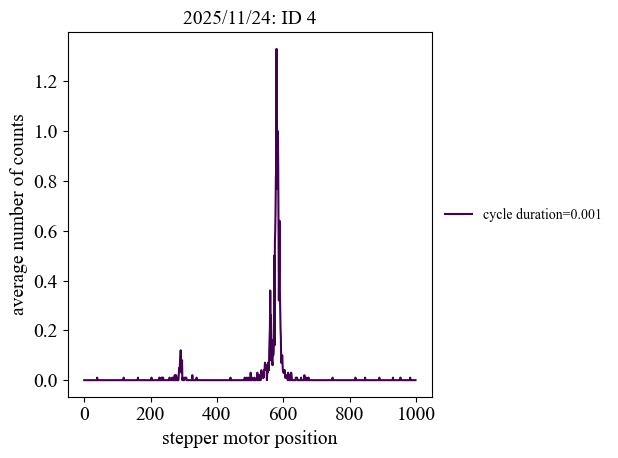

In [152]:
ps.Plot2D(x = x_list, y = T, Z = results, xlabel = "stepper motor position", ylabel = "cycle duration", zlabel = "average number of counts")

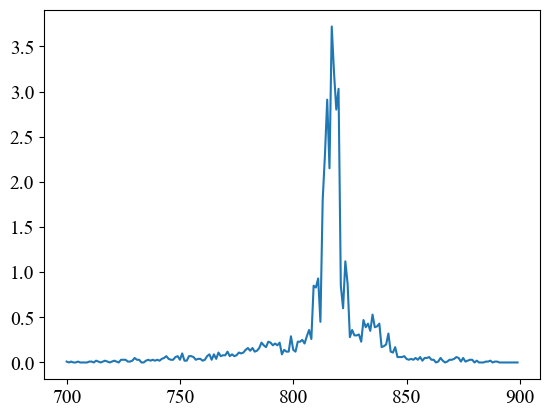

In [212]:
plt.plot(x_list[700:900],results[700:900])

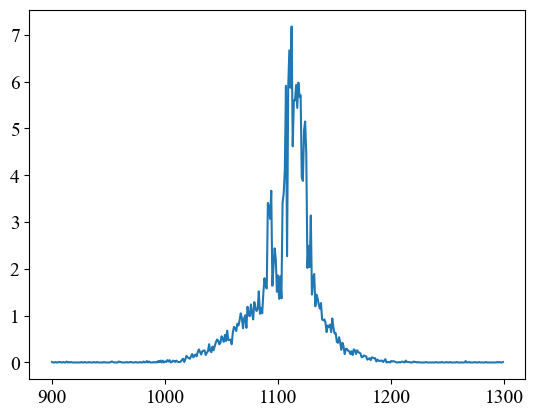

In [213]:
plt.plot(x_list[900:1300],results[900:1300])

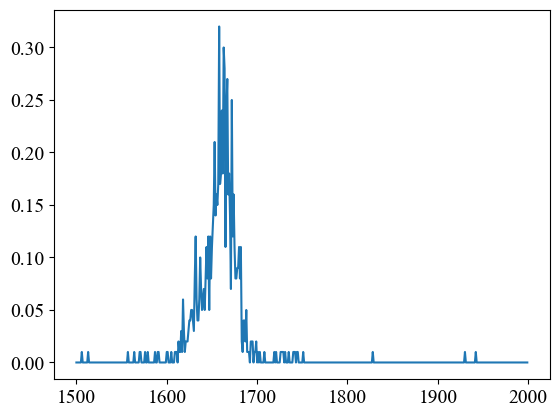

In [214]:
plt.plot(x_list[1500:2000],results[1500:2000])

**5P 3/2 -- 50 D 3/2 resonance at stepper motor position 3722.**

In [ ]:
weeder.save(header = "A", query = True)